# Data Practicum II - Learning Analytics Spotting an At-Risk Student in Time

- Data Pre-Processing
- Baseline Modeling
  - Regression Modeling

## Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Loading Data
import pandas as pd

df_withdrawn = pd.read_csv('/content/drive/MyDrive/df_withdrawn.csv')
df_withdrawn.head()


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_unregistration,id_assessment,date_submitted,is_banked,score,assessment_type,date,weight,id_site,sum_click
0,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,546614.0,59.0
1,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,546645.0,4.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,546650.0,1.0
3,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,546652.0,45.0
4,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,546654.0,7.0


### Feature Engineering

We will create three new features:
1.  **`last_assessment_date`**: The last date an assessment was submitted by each student for a given module presentation.
2.  **`survival_days_ratio`**: The ratio of the last day a student submitted an assessment to the total duration of the module presentation. This indicates how long a student 'survived' or remained active in the class relative to its full length.
3.  **`assessment_submission_timeliness`**: The difference between the assessment's official `date` and the student's `date_submitted`, to measure how timely an assessment was submitted.

In [3]:
# Calculate the last assessment date for each student within their module and presentation
# We will use 'date_submitted' for this, and fill NaNs with a value (e.g., 0) if appropriate, or handle them.
# For 'last assessment date', we need to consider the maximum 'date_submitted' a student has for a given module and presentation.
# Using transform to add this directly as a new column while maintaining the original DataFrame shape.
df_withdrawn['last_assessment_date'] = df_withdrawn.groupby(['id_student', 'code_module', 'code_presentation'])['date_submitted'].transform('max')

In [4]:
# To calculate 'survival', we need the total duration of each module presentation.
# The 'date' column in the original dataset likely refers to the assessment date relative to the module start.
# We'll assume the maximum 'date' value for a given module and presentation represents its total duration in days.

df_withdrawn['total_module_duration'] = df_withdrawn.groupby(['code_module', 'code_presentation'])['date'].transform('max')

# Calculate the 'survival' ratio: (last day student submitted) / (total module duration)
# We use 'last_assessment_date' (which is max date_submitted) as the numerator.
# Handle cases where 'total_module_duration' might be zero to prevent division by zero.
df_withdrawn['survival_days_ratio'] = df_withdrawn['last_assessment_date'] / df_withdrawn['total_module_duration']

# Handle potential NaN values or infinities that might arise from division by zero or missing data
df_withdrawn['survival_days_ratio'] = df_withdrawn['survival_days_ratio'].replace([float('inf'), -float('inf')], float('nan'))
df_withdrawn['survival_days_ratio'] = df_withdrawn['survival_days_ratio'].fillna(0) # or another appropriate value

In [5]:
# Calculate assessment_submission_timeliness: date - date_submitted
df_withdrawn['assessment_submission_timeliness'] = df_withdrawn['date'] - df_withdrawn['date_submitted']

In [6]:
# Display the DataFrame with the new features, including assessment_submission_timeliness
display(df_withdrawn[['id_student', 'code_module', 'code_presentation', 'date_submitted', 'last_assessment_date', 'date', 'total_module_duration', 'survival_days_ratio', 'assessment_submission_timeliness']].head())

,id_student,code_module,code_presentation,date_submitted,last_assessment_date,date,total_module_duration,survival_days_ratio,assessment_submission_timeliness
0,30268,AAA,2013J,NaN,NaN,NaN,215.0,0.0,NaN
1,30268,AAA,2013J,NaN,NaN,NaN,215.0,0.0,NaN
2,30268,AAA,2013J,NaN,NaN,NaN,215.0,0.0,NaN
3,30268,AAA,2013J,NaN,NaN,NaN,215.0,0.0,NaN
4,30268,AAA,2013J,NaN,NaN,NaN,215.0,0.0,NaN


In [7]:
df_withdrawn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 761705 entries, 0 to 761704
Data columns (total 27 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   code_module                       761705 non-null  object 
 1   code_presentation                 761705 non-null  object 
 2   id_student                        761705 non-null  int64  
 3   gender                            761705 non-null  object 
 4   region                            761705 non-null  object 
 5   highest_education                 761705 non-null  object 
 6   imd_band                          728807 non-null  object 
 7   age_band                          761705 non-null  object 
 8   num_of_prev_attempts              761705 non-null  int64  
 9   studied_credits                   761705 non-null  int64  
 10  disability                        761705 non-null  object 
 11  final_result                      761705 non-null  o

### Categorical Variable Encoding

We will encode categorical features into a numerical format suitable for machine learning models. One-hot encoding will be applied to nominal categorical variables to avoid implying any ordinal relationship.

In [8]:
# Identify categorical columns for encoding
categorical_cols = df_withdrawn.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude 'final_result' from one-hot encoding as requested
if 'final_result' in categorical_cols:
    categorical_cols.remove('final_result')

# Perform one-hot encoding
df_withdrawn_encoded = pd.get_dummies(df_withdrawn, columns=categorical_cols, drop_first=True)

print(f"Original DataFrame shape: {df_withdrawn.shape}")
print(f"Encoded DataFrame shape: {df_withdrawn_encoded.shape}")

# Display the head of the encoded DataFrame to show the new columns
display(df_withdrawn_encoded.head())

Original DataFrame shape: (761705, 27)
Encoded DataFrame shape: (761705, 58)


,id_student,num_of_prev_attempts,studied_credits,final_result,date_registration,date_unregistration,id_assessment,date_submitted,is_banked,score,...,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,age_band_35-55,age_band_55<=,disability_Y,assessment_type_Exam,assessment_type_TMA
0,30268,0,60,Withdrawn,-92.0,12.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,False,True,False,False
1,30268,0,60,Withdrawn,-92.0,12.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,False,True,False,False
2,30268,0,60,Withdrawn,-92.0,12.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,False,True,False,False
3,30268,0,60,Withdrawn,-92.0,12.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,False,True,False,False
4,30268,0,60,Withdrawn,-92.0,12.0,NaN,NaN,NaN,NaN,...,False,False,False,False,False,True,False,True,False,False


### Evolution of Student Withdrawal Across Dates

To understand the temporal patterns of student withdrawal, we will visualize the count of student activities (assessments, interactions) and the average `survival_days_ratio` over time. This helps in identifying specific periods where students are more likely to withdraw or exhibit lower engagement.

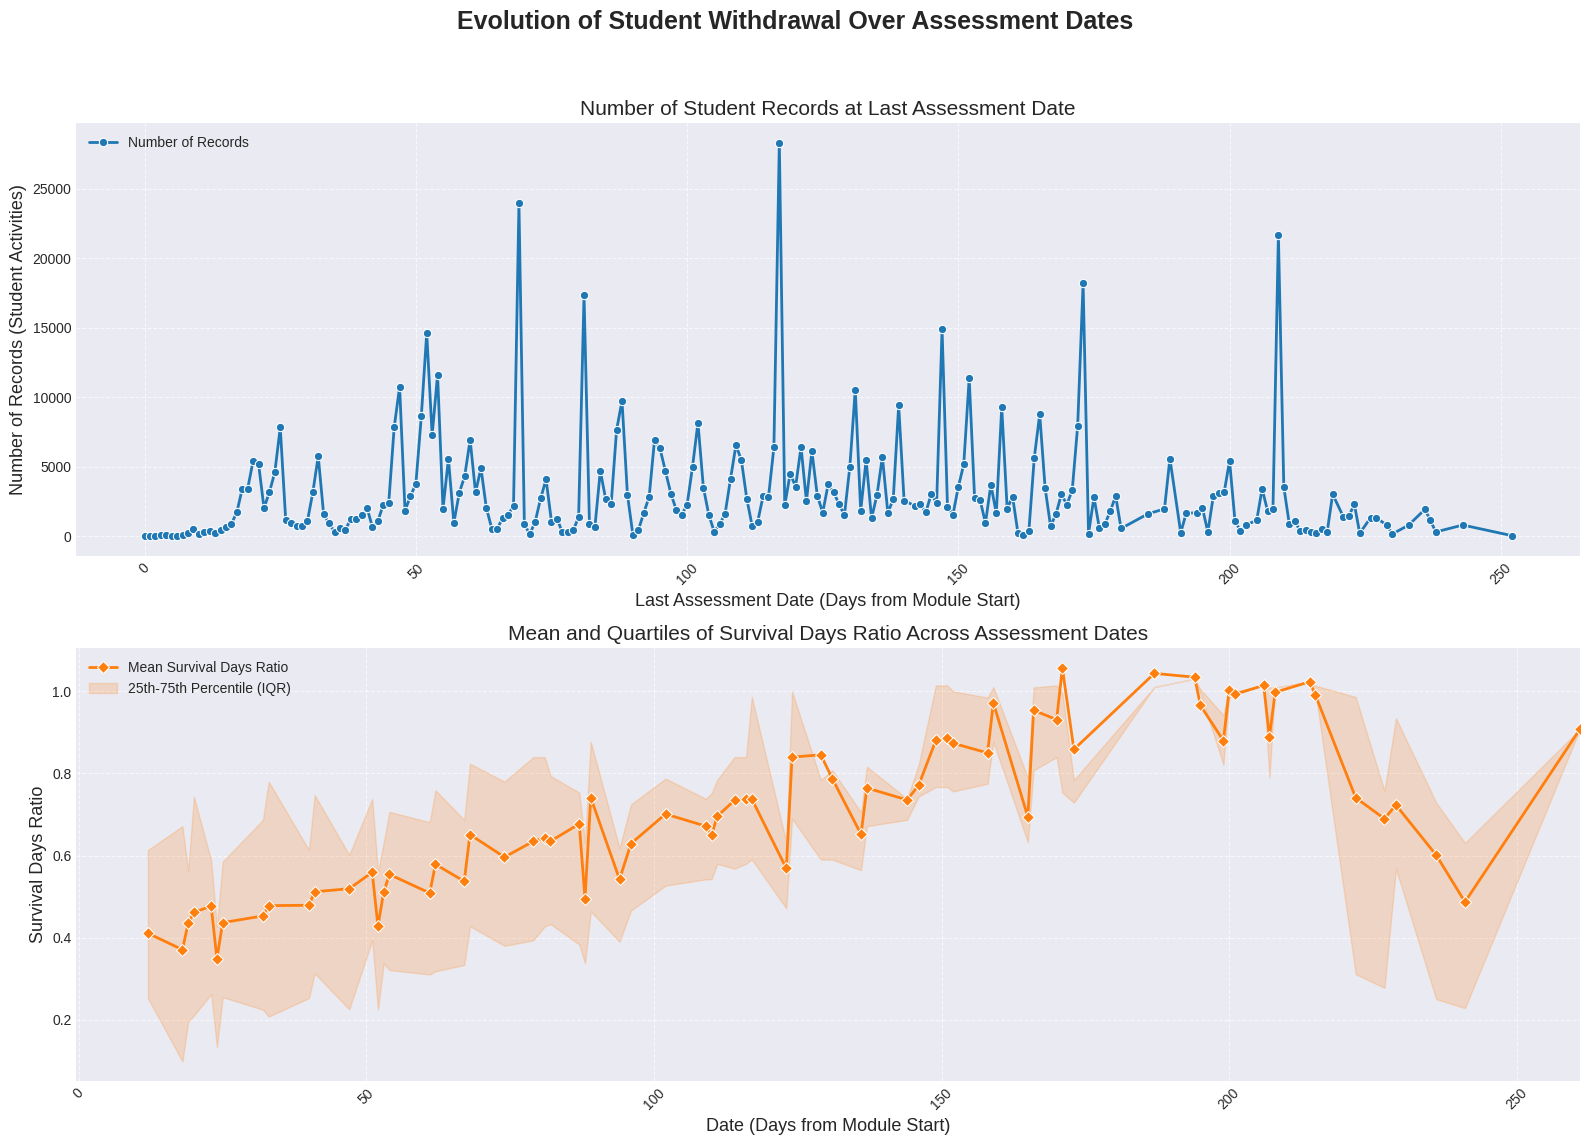

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply a modern seaborn style for better aesthetics
plt.style.use('seaborn-v0_8-darkgrid')

# Group by 'last_assessment_date' to get counts of records for the first plot.
daily_withdrawal_counts = df_withdrawn.groupby('last_assessment_date').agg(
    count_records=('id_student', 'count')
).reset_index()

# Sort by last_assessment_date for proper time series plotting
daily_withdrawal_counts = daily_withdrawal_counts.sort_values(by='last_assessment_date')

# Filter daily_withdrawal_counts to include only data points within the range [0, 261]
daily_withdrawal_counts = daily_withdrawal_counts[(daily_withdrawal_counts['last_assessment_date'] >= 0) & (daily_withdrawal_counts['last_assessment_date'] <= 261)]

# Group by 'date' to calculate mean and quartiles for survival_days_ratio (for the second plot).
daily_survival_summary = df_withdrawn.groupby('date')['survival_days_ratio'].agg(
    mean_ratio='mean',
    q25_ratio=lambda x: x.quantile(0.25),
    q75_ratio=lambda x: x.quantile(0.75)
).reset_index()

daily_survival_summary = daily_survival_summary.sort_values(by='date')

# Set up the figure and axes for two subplots, without sharing the x-axis
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False) # Changed sharex to False
fig.suptitle('Evolution of Student Withdrawal Over Assessment Dates', fontsize=18, fontweight='bold')

# --- Plot 1: Count of Withdrawn Student Records at Last Assessment Date ---
sns.lineplot(
    x='last_assessment_date', # Changed to last_assessment_date
    y='count_records',
    data=daily_withdrawal_counts,
    ax=axes[0],
    color='#1f77b4',
    marker='o',
    markersize=6,
    linewidth=2,
    linestyle='-',
    label='Number of Records'
)
axes[0].set_title('Number of Student Records at Last Assessment Date', fontsize=15) # Updated title
axes[0].set_ylabel('Number of Records (Student Activities)', fontsize=13)
axes[0].set_xlabel('Last Assessment Date (Days from Module Start)', fontsize=13) # Added x-label for top plot
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.7)

# The x-axis limit will now be automatically set by the filtered data, or can be explicitly set if needed
# axes[0].set_xlim(left=0, right=261) # This line is no longer strictly necessary if data is filtered

# --- Plot 2: Mean Survival Days Ratio with Quartile Fan (remains grouped by 'date') ---
sns.lineplot(
    x='date',
    y='mean_ratio',
    data=daily_survival_summary,
    ax=axes[1],
    color='#ff7f0e',
    marker='D',
    markersize=6,
    linewidth=2,
    linestyle='-',
    label='Mean Survival Days Ratio'
)

axes[1].fill_between(
    daily_survival_summary['date'],
    daily_survival_summary['q25_ratio'],
    daily_survival_summary['q75_ratio'],
    color='#ff7f0e',
    alpha=0.2,
    label='25th-75th Percentile (IQR)'
)

axes[1].set_title('Mean and Quartiles of Survival Days Ratio Across Assessment Dates', fontsize=15)
axes[1].set_xlabel('Date (Days from Module Start)', fontsize=13) # Keep original x-label for second plot
axes[1].set_ylabel('Survival Days Ratio', fontsize=13)
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Apply xticks rotation to both subplots individually if desired
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Set x-axis limit for the second plot
max_date_overall = daily_survival_summary['date'].max()
axes[1].set_xlim(right=max_date_overall)

plt.show()

### Findings from Evolution of Student Withdrawal Across Assessment Dates

1.  **Count of Withdrawn Student Records at Last Assessment Date (Top Plot)**:
    *   The line chart illustrates the frequency of student whoi submitted their very last assessment for a given assessment date (that is sumbitted their last assessment for the given assessement date and withdrew thereafter), covering `last_assessment_date` values **between 0 and 261**; the data for this plot has been filtered to this range to consider only the duration for the class and not extended submission dates.
    *   Within this range, the plot shows various fluctuations. Peaks in withdrawal activity likely corresponding to major assessment deadlines or critical points in the module, where students might face challenges leading to withdrawal; the high number of withdrawals occurring around specific assessment dates indicate that these points are critical points for student retention.

2.  **Mean and Quartiles of Survival Days Ratio Across Assessment Dates (Bottom Plot)**:
    *   The line chart displayed the average `survival_days_ratio` for withdrawn students, along with the 25th and 75th percentiles (interquartile range).
    *   The **mean survival days ratio** generally demonstrates an increasing trend as the `date` progresses. For example, at `date = 12.0`, the mean ratio is approximately `0.41`, whereas by `date = 261.0`, it reaches around `0.91`. This is expected, as students who withdraw later in the module will inherently have a higher ratio.
    *   The **quartile fan** provides insights into the variability of withdrawal timing. Early in the module (e.g., around `date = 12.0`), the fan is relatively wide (ranging from `0.25` to `0.61`), indicating a broader spread in when students withdraw relative to the module duration. As we approach the end of the observed date range (e.g., `date = 261.0`), the fan becomes very narrow (from `0.90` to `0.91`), suggesting a more consistent `survival_days_ratio` among those who withdraw at this late stage.
    *   Noticeable dips in the mean ratio, such as around `date = 236.0` where the mean is `0.60` (after a higher `0.72` at `date = 229.0`), suggest specific periods where withdrawn students, on average, exhibited a relatively shorter period of activity compared to adjacent periods. This could highlight points of increased difficulty or disengagement.

## Baseline Modeling

### Regression Decision Tree Modeling

We will use a Decision Tree Regressor to establish a baseline model. The target variable for this model will be `survival_days_ratio`. We'll include features such as `date` (to capture the assessment stage), `assessment_submission_timeliness`, and other numerical features that could influence student survival.

**Objective**: Predict `survival_days_ratio` based on student and assessment-related features.

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define features (X) and target (y)
# Including 'date' and 'assessment_submission_timeliness' as requested.
# Other relevant numerical features are selected. Categorical features have been encoded.

target = 'survival_days_ratio'

# Get all columns from df_withdrawn_encoded that are not the target or 'final_result'
# and are not other identifier or intermediate columns.

# Exclude 'final_result' and target from features, along with other non-feature columns
excluded_cols = ['final_result', target, 'id_student', 'date_registration', 'date_unregistration',
                 'id_assessment', 'date_submitted', 'id_site', 'assessment_submission_timeliness',
                 'total_module_duration', 'last_assessment_date']

features = [col for col in df_withdrawn_encoded.columns if col not in excluded_cols]

# Drop rows where target or features might be NaN to ensure model training can proceed.
# For a more robust approach, consider imputation strategies.
model_df = df_withdrawn_encoded[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Features used for modeling: {features[:5]}... and {len(features) - 5} more features")

Training set size: 575500 samples
Testing set size: 143876 samples
Features used for modeling: ['num_of_prev_attempts', 'studied_credits', 'is_banked', 'score', 'date']... and 42 more features


In [11]:
# Initialize and train the Decision Tree Regressor model
dt_regressor = DecisionTreeRegressor(random_state=42, max_depth=15)
dt_regressor.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=15, random_state=42)

In [12]:
# Make predictions on the test set
y_pred = dt_regressor.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.1023
R-squared (R2): 0.7645


### Findings from Regression Decision Tree Model Evaluation

The Decision Tree Regressor achieved the following performance metrics on the test set with `max_depth=15`:

*   **Mean Absolute Error (MAE): 0.1023**: This indicates that, on average, the model's predictions for the `survival_days_ratio` differ from the actual values by approximately 0.1023.
*   **R-squared (R2): 0.7645**: An R-squared value of 0.7645 means that approximately 76.45% of the variance in the `survival_days_ratio` can be explained by the features included in the model; indicating that the model has a good explanatory power for the variability in student survival days.

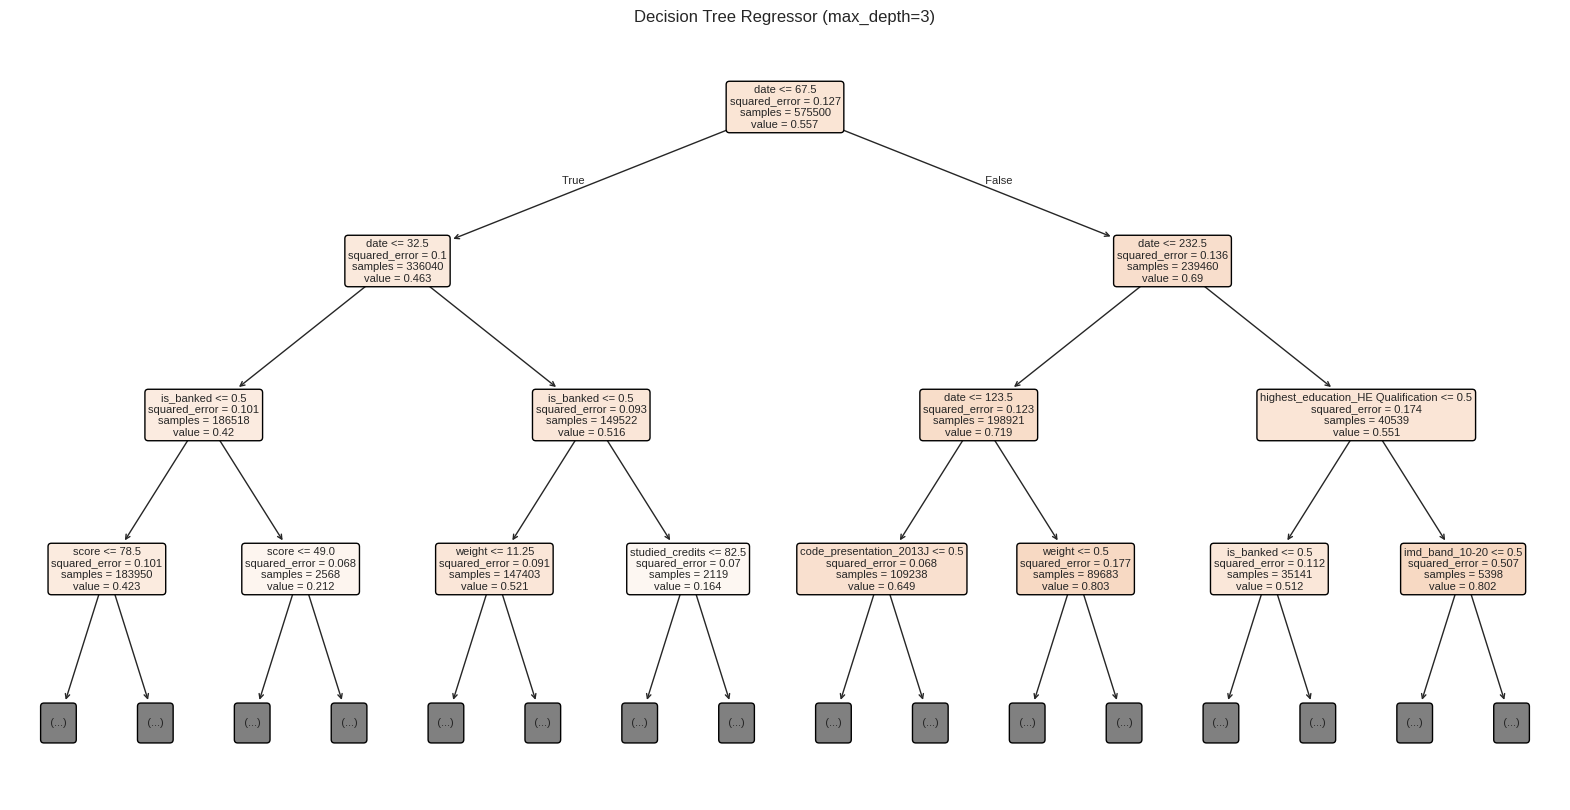

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set the figure size appropriately. For very deep trees, this might still be too dense.
plt.figure(figsize=(20, 10))

# Plot the decision tree. You can adjust max_depth for better readability.
plot_tree(dt_regressor,
          feature_names=X.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Limiting depth for better visualization

plt.title('Decision Tree Regressor (max_depth=3)')
plt.show()

### Findings from Regression Decision Tree Plot

**Overall Structure and Key Predictors:**

The tree's root highlights **assessment date** (`date ≤ 67.5`) as the most critical predictor, indicating that student withdrawal risk is highly **time-dependent**. Students' behavior changes significantly after the first ~68 days of the course.

**Key Stages and Influencing Factors:**

1.  **Early Course (Days 0-67):** The first month (`date ≤ 32.5`) is a critical period. In this stage, academic performance (`score`) and whether an assessment was `is_banked` (carried over from previous attempts) are strong indicators. Students with lower scores (e.g., below 79) and normal assessments face a higher withdrawal risk (about 42%), compared to those with better scores (about 21%). Further into the early-middle course (Days 33-67), `is_banked` status and assessment `weight` become influential, suggesting that engagement with more substantial assessments impacts risk.

2.  **Later Course (Days > 67.5):** Beyond the initial two months, the average withdrawal probability is higher. In the mid-course (`date ≤ 123.5`), `code_presentation` (different offerings of the course) emerges as a contextual factor, and `weight` continues to distinguish risk profiles. For students who remain active very late in the course (`date > 232.5`), demographic factors like `highest_education` and socioeconomic status (`imd_band`) become more prominent in explaining withdrawal.

**Hierarchy of Variable Importance:**

The tree's structure suggests a hierarchy of importance:
1.  **Assessment date:** Strongest indicator of risk evolution.
2.  **Assessment score:** Direct link to academic performance and withdrawal.
3.  **Banked assessment:** Reflects prior academic history.
4.  **Assessment weight:** Indicates engagement with high-stakes assessments.
5.  **Studied credits:** Implies workload and capacity.
6.  **Course presentation:** Contextual factors of different offerings.
7.  **Highest education:** Prior educational attainment.
8.  **IMD band:** Socioeconomic background.

**Practical Implications for Early Warning:**

This suggests a **staged intervention strategy**:
*   **Weeks 1-4:** Focus on academic support (tutoring, study skills) for students with low assessment scores.
*   **Weeks 5-9:** Monitor for missed/low-weight assessments and high study loads; provide workload planning and assignment reminders.
*   **Later Stages (Weeks 10+):** Offer targeted interventions like financial aid, mentoring, and counseling, especially for students identified with higher risk due to educational background or socioeconomic disadvantage.



### Feature Importance

Understanding feature importance can help identify which variables the model considers most significant in predicting the `survival_days_ratio`. This can provide insights into the underlying patterns in the data.

Top 10 Feature Importances:


,0
date,0.203355
score,0.117090
studied_credits,0.067255
highest_education_Lower Than A Level,0.041523
region_South West Region,0.037521
imd_band_10-20,0.037032
highest_education_HE Qualification,0.033704
imd_band_20-30%,0.030787
num_of_prev_attempts,0.029075
weight,0.022613


/tmp/ipykernel_964/2977923083.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df.head(10).values, y=feature_importance_df.head(10).index, palette=colors, ax=ax)


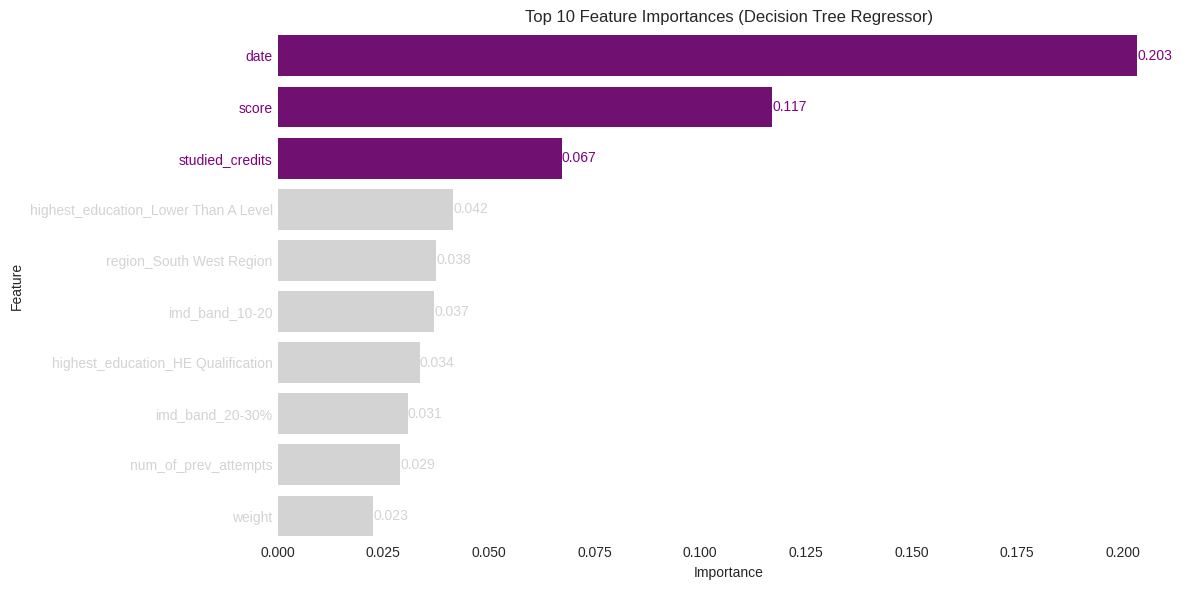

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Decision Tree Regressor
feature_importances = dt_regressor.feature_importances_

# Create a Series for better readability
feature_importance_df = pd.Series(feature_importances, index=X.columns)

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(ascending=False)

# Display the top N most important features
print("Top 10 Feature Importances:")
display(feature_importance_df.head(10))

# Define colors based on importance threshold
importance_threshold = 0.05
colors = ['purple' if imp > importance_threshold else 'lightgray' for imp in feature_importance_df.head(10).values]

# Visualize the feature importances
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white') # Set figure background to white
ax.set_facecolor('white') # Set axes background to white

sns.barplot(x=feature_importance_df.head(10).values, y=feature_importance_df.head(10).index, palette=colors, ax=ax)
plt.title('Top 10 Feature Importances (Decision Tree Regressor)')
plt.xlabel('Importance')
plt.ylabel('Feature')

# Remove grid
ax.grid(False)

# Set feature label colors consistent with bar colors
for i, label in enumerate(ax.get_yticklabels()):
    label.set_color(colors[i])

# Add data labels consistent with bar colors
for i, (p, value) in enumerate(zip(ax.patches, feature_importance_df.head(10).values)):
    ax.text(p.get_width(), p.get_y() + p.get_height() / 2, f'{value:.3f}',
            va='center', color=colors[i], fontsize=10)

plt.tight_layout()
plt.show()

### Findings from Feature Importance Analysis

The feature importance analysis from the Decision Tree Regressor shows that the most influential features in predicting the `survival_days_ratio`:

*   **`date`**: With the highest importance, the `date` (assessment date from module start) is the most critical feature. This suggests that the timing of assessments or student activity relative to the module timeline is a primary driver of how long students 'survive' before withdrawing.
*   **`score`**: The `score` on assessments is the second most important feature. This is intuitively sensible; students performing well (higher scores) are likely to remain engaged longer, while consistently low scores might precede withdrawal.
*   **`studied_credits`**: The number of `studied_credits` is also highly influential. This could reflect a student's workload, commitment, or academic capacity, all of which might impact their persistence in a module.
*   **Categorical Features**: Several one-hot encoded categorical features (e.g., `highest_education`, `imd_band`, `region`) also appear in the top importances, indicating that demographic and educational background factors play a significant role in predicting student survival. For example, specific `imd_band` (Index of Multiple Deprivation) categories or `highest_education` levels can differentiate withdrawal patterns.

These findings suggest that a combination of temporal factors (`date`), academic performance (`score`), and student characteristics (`studied_credits`, demographic features) are key predictors of student withdrawal patterns, as captured by the `survival_days_ratio`.

## Advanced Modeling

### Random Forest Regression Modeling

We will now use a Random Forest Regressor to potentially improve upon the baseline model. Random Forests are ensemble learning methods that can capture more complex relationships and often provide better predictive performance than single decision trees by averaging multiple decision trees trained on different subsets of the data.

**Objective**: Predict `survival_days_ratio` using a Random Forest model and assess its performance against the Decision Tree Regressor.

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# Using similar parameters to Decision Tree initially, but Random Forest generally benefits from more trees.
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_regressor.predict(X_test)

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Random Forest R-squared (R2): {r2_rf:.4f}")

Random Forest Mean Absolute Error (MAE): 0.0915
Random Forest R-squared (R2): 0.8459


### Findings from Random Forest Regression Model Evaluation

The Random Forest Regressor achieved the following performance metrics on the test set with `max_depth=15` and `n_estimators=100`:

*   **Mean Absolute Error (MAE):** 0.0915 This indicates that, on average, the Random Forest model's predictions for the `survival_days_ratio` are more accurate than the Decision Tree Regressor if the MAE is lower.
*   **R-squared (R2):** 0.8459 An R-squared value of 0.8459 suggests that the Random Forest model explains a significant portion of the variance in the `survival_days_ratio`, potentially outperforming the single Decision Tree model if the R2 is higher.

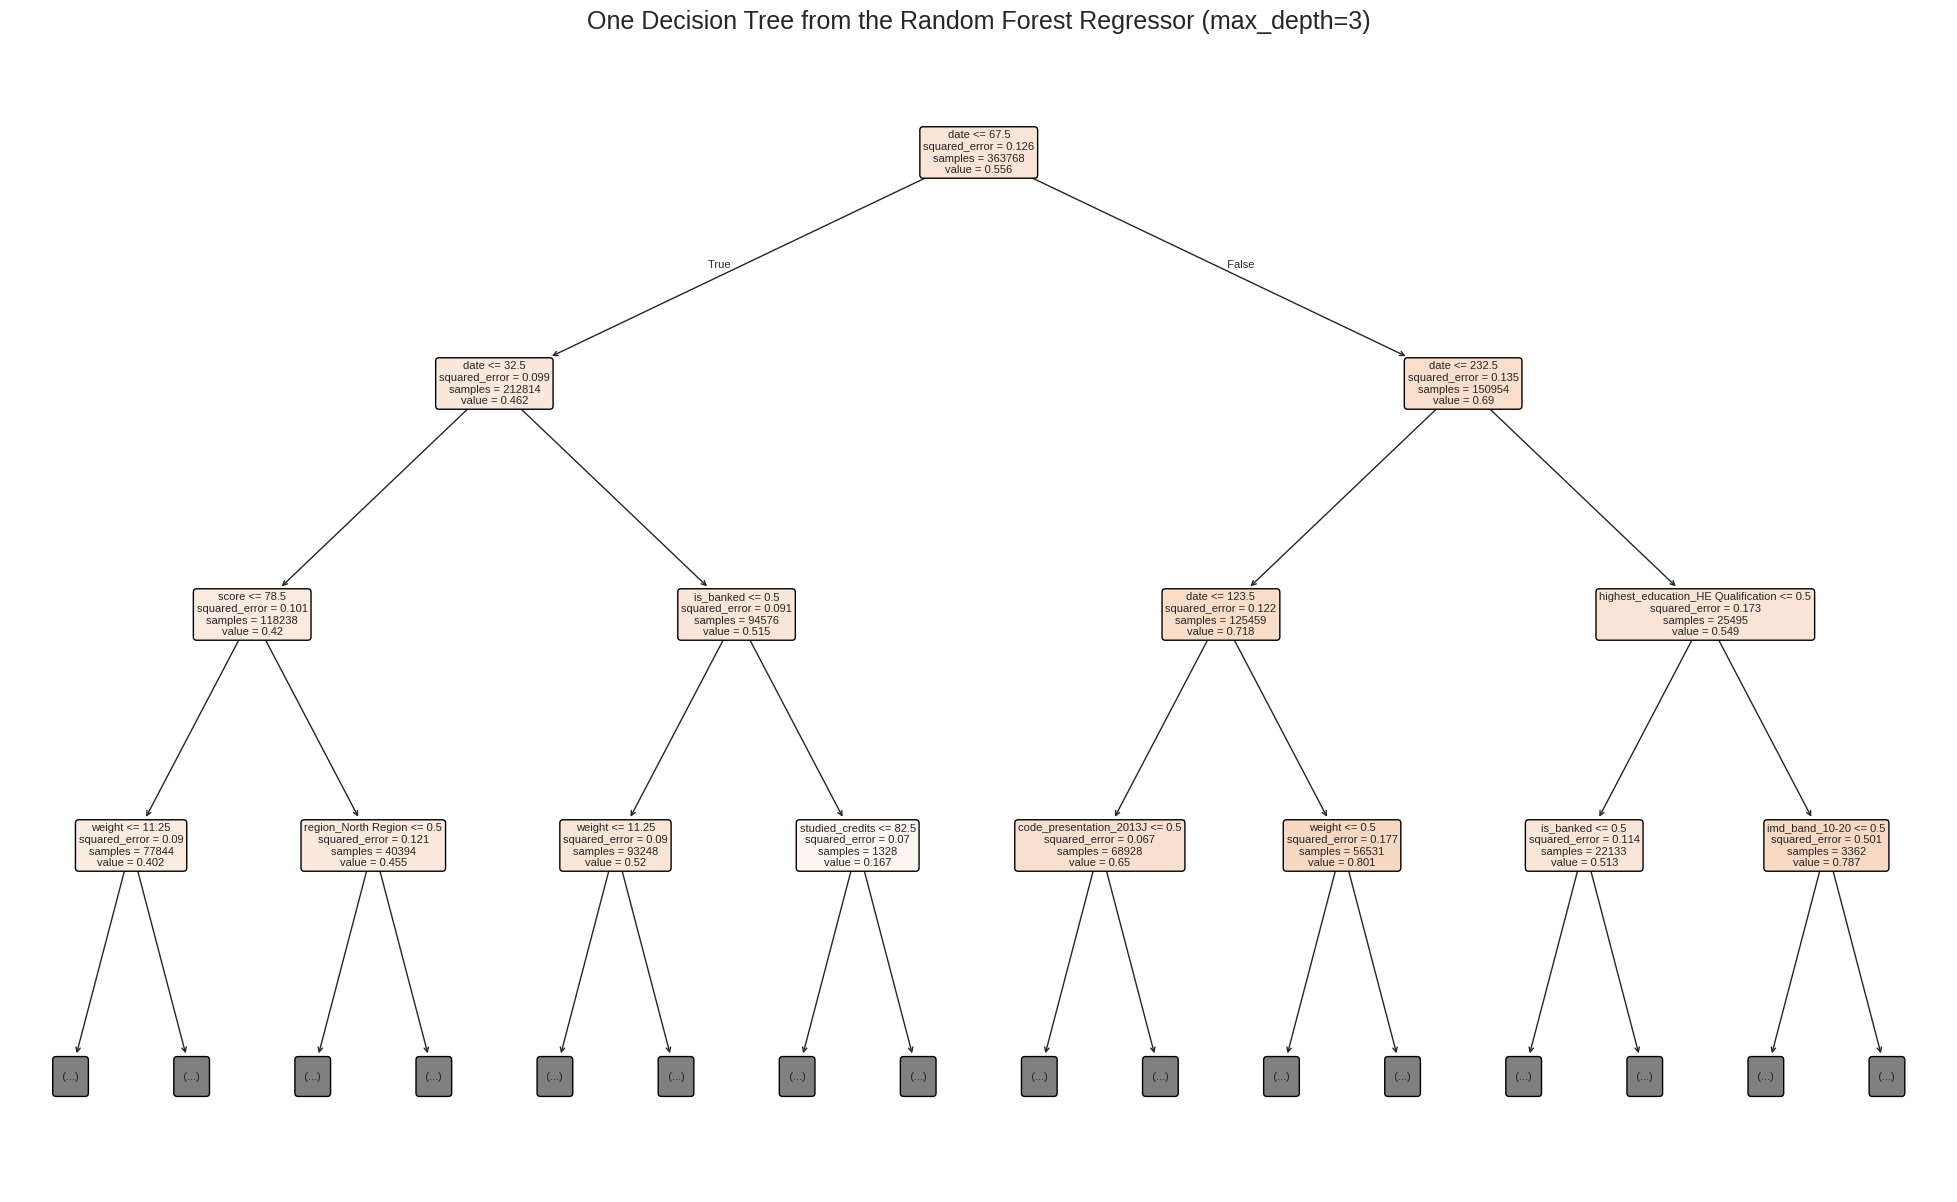

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get one of the estimators (individual decision trees) from the Random Forest
# For example, let's take the first tree in the forest
one_tree_from_rf = rf_regressor.estimators_[0]

plt.figure(figsize=(25, 15)) # Adjust figure size for better readability

plot_tree(one_tree_from_rf,
          feature_names=X.columns.tolist(), # Use the same feature names as for the full model
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Limiting depth for better visualization, as with the single DT

plt.title('One Decision Tree from the Random Forest Regressor (max_depth=3)', fontsize=18)
plt.show()

### Feature Importance (Random Forest)

Top 10 Feature Importances (Random Forest):


,0
date,0.210442
score,0.108535
studied_credits,0.067172
imd_band_10-20,0.039070
region_South West Region,0.035449
highest_education_Lower Than A Level,0.034796
highest_education_HE Qualification,0.033041
imd_band_20-30%,0.024435
gender_M,0.024262
num_of_prev_attempts,0.024211


/tmp/ipykernel_964/1714618397.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df_rf.head(10).values, y=feature_importance_df_rf.head(10).index, palette=colors_rf, ax=ax)


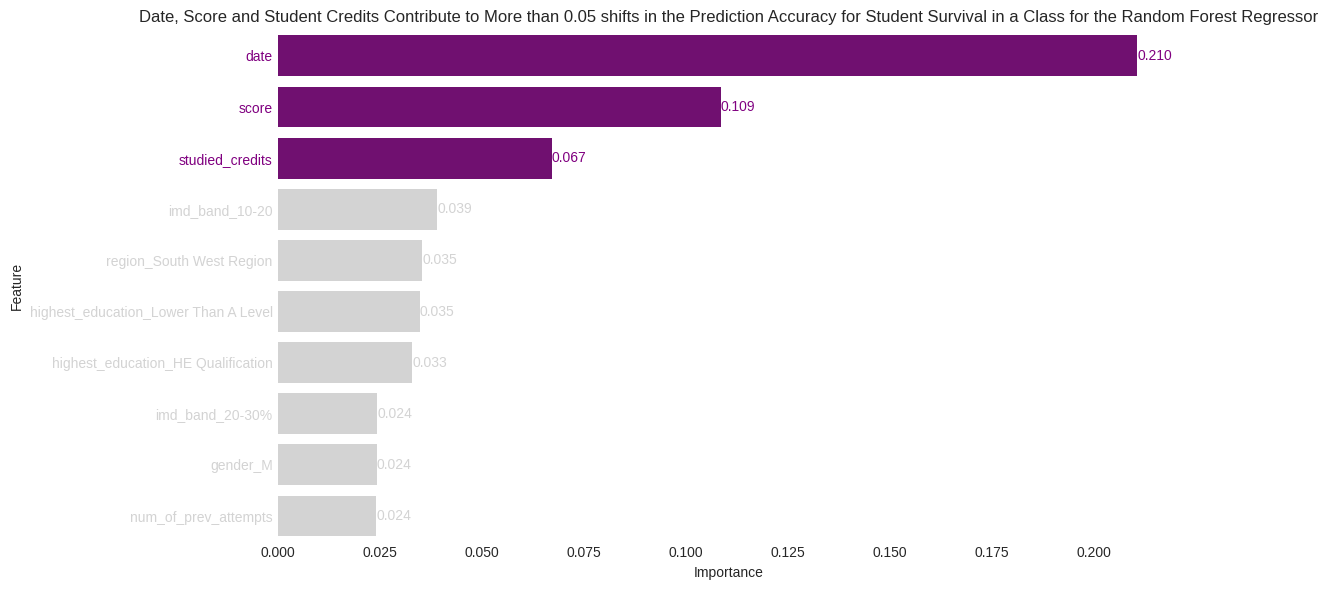

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest Regressor
feature_importances_rf = rf_regressor.feature_importances_

# Create a Series for better readability
feature_importance_df_rf = pd.Series(feature_importances_rf, index=X.columns)

# Sort features by importance in descending order
feature_importance_df_rf = feature_importance_df_rf.sort_values(ascending=False)

# Display the top N most important features
print("Top 10 Feature Importances (Random Forest):")
display(feature_importance_df_rf.head(10))

# Define colors based on importance threshold
importance_threshold = 0.05
colors_rf = ['purple' if imp > importance_threshold else 'lightgray' for imp in feature_importance_df_rf.head(10).values]

# Visualize the feature importances
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white') # Set figure background to white
ax.set_facecolor('white') # Set axes background to white

sns.barplot(x=feature_importance_df_rf.head(10).values, y=feature_importance_df_rf.head(10).index, palette=colors_rf, ax=ax)
plt.title('Date, Score and Student Credits Contribute to More than 0.05 shifts in the Prediction Accuracy for Student Survival in a Class for the Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')

# Remove grid
ax.grid(False)

# Set feature label colors consistent with bar colors
for i, label in enumerate(ax.get_yticklabels()):
    label.set_color(colors_rf[i])

# Add data labels consistent with bar colors
for i, (p, value) in enumerate(zip(ax.patches, feature_importance_df_rf.head(10).values)):
    ax.text(p.get_width(), p.get_y() + p.get_height() / 2, f'{value:.3f}',
            va='center', color=colors_rf[i], fontsize=10)

plt.tight_layout()
plt.show()

### Findings from Random Forest Feature Importance Analysis

•	date: With the highest importance, the date (assessment date from module start) is the most critical feature. This suggests that the timing of assessments or student activity relative to the module timeline is a primary driver of how long students 'survive' before withdrawing.

•	score: The score on assessments is the second most important feature. This is intuitively sensible; students performing well (higher scores) are likely to remain engaged longer, while consistently low scores might precede withdrawal.

•	studied_credits: The number of studied_credits is also highly influential. This could reflect a student's workload, commitment, or academic capacity, all of which might impact their persistence in a module.

•	Categorical Features: Several one-hot encoded categorical features (e.g., highest_education, imd_band, region) also appear in the top importances, indicating that demographic and educational background factors play a significant role in predicting student survival. For example, specific imd_band (Index of Multiple Deprivation) categories or highest_education levels can differentiate withdrawal patterns.


### Gradient Boosting Regression Modeling

Gradient Boosting is another powerful ensemble technique that builds models sequentially, where each new tree corrects errors made by previous ones. It can often achieve high accuracy and is robust to overfitting.

**Objective**: Predict `survival_days_ratio` using a Gradient Boosting model and assess its performance.

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the Gradient Boosting Regressor model
# Using n_estimators=100 and max_depth=5 as a starting point.
gbr_regressor = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbr_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbr = gbr_regressor.predict(X_test)

# Evaluate the Gradient Boosting model
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting Mean Absolute Error (MAE): {mae_gbr:.4f}")
print(f"Gradient Boosting R-squared (R2): {r2_gbr:.4f}")

Gradient Boosting Mean Absolute Error (MAE): 0.1816
Gradient Boosting R-squared (R2): 0.4887


### Feature Importance (Gradient Boosting)

Top 10 Feature Importances (Gradient Boosting):


,0
date,0.311672
imd_band_10-20,0.051249
region_South West Region,0.047951
studied_credits,0.046658
code_module_FFF,0.039627
score,0.038161
imd_band_70-80%,0.035462
region_Scotland,0.031687
age_band_35-55,0.030100
region_North Region,0.030052


/tmp/ipykernel_964/2649454699.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df_gbr.head(10).values, y=feature_importance_df_gbr.head(10).index, palette=colors_gbr, ax=ax)


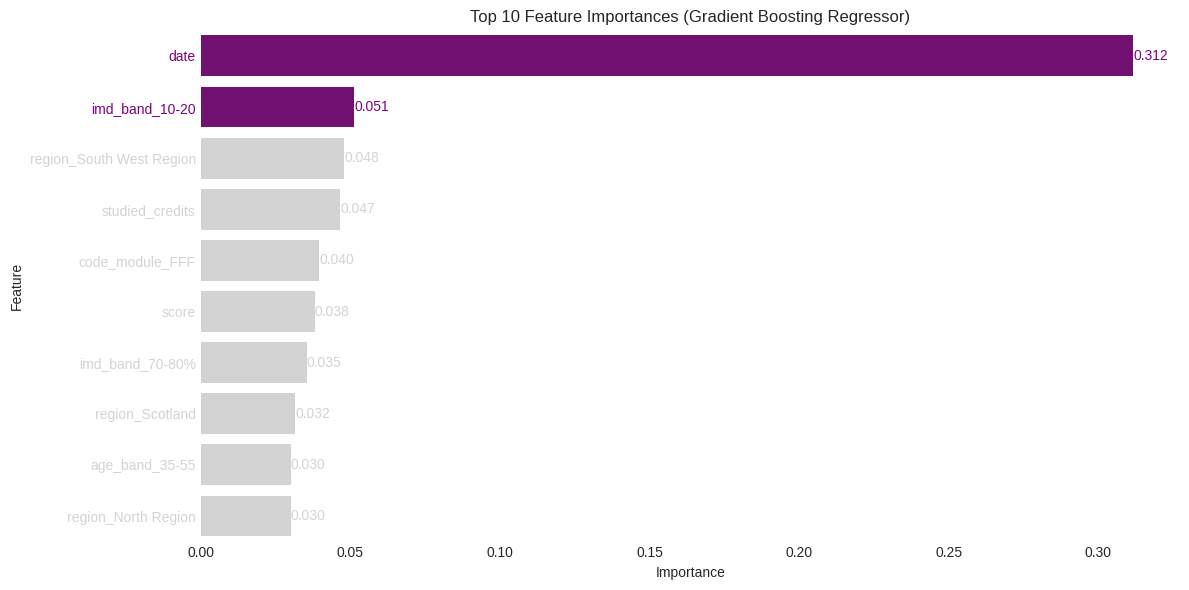

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Gradient Boosting Regressor
feature_importances_gbr = gbr_regressor.feature_importances_

# Create a Series for better readability
feature_importance_df_gbr = pd.Series(feature_importances_gbr, index=X.columns)

# Sort features by importance in descending order
feature_importance_df_gbr = feature_importance_df_gbr.sort_values(ascending=False)

# Display the top N most important features
print("Top 10 Feature Importances (Gradient Boosting):")
display(feature_importance_df_gbr.head(10))

# Define colors based on importance threshold
importance_threshold = 0.05
colors_gbr = ['purple' if imp > importance_threshold else 'lightgray' for imp in feature_importance_df_gbr.head(10).values]

# Visualize the feature importances
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white') # Set figure background to white
ax.set_facecolor('white') # Set axes background to white

sns.barplot(x=feature_importance_df_gbr.head(10).values, y=feature_importance_df_gbr.head(10).index, palette=colors_gbr, ax=ax)
plt.title('Top 10 Feature Importances (Gradient Boosting Regressor)')
plt.xlabel('Importance')
plt.ylabel('Feature')

# Remove grid
ax.grid(False)

# Set feature label colors consistent with bar colors
for i, label in enumerate(ax.get_yticklabels()):
    label.set_color(colors_gbr[i])

# Add data labels consistent with bar colors
for i, (p, value) in enumerate(zip(ax.patches, feature_importance_df_gbr.head(10).values)):
    ax.text(p.get_width(), p.get_y() + p.get_height() / 2, f'{value:.3f}',
            va='center', color=colors_gbr[i], fontsize=10)

plt.tight_layout()
plt.show()

## Model Performance Comparison (R-squared)

In [28]:
# Create a dictionary to store R2 scores
r2_scores = {
    'Decision Tree Regressor': r2,
    'Random Forest Regressor': r2_rf,
    'Gradient Boosting Regressor': r2_gbr
}

# Convert to a pandas Series for easy comparison and display
r2_series = pd.Series(r2_scores).sort_values(ascending=False)

print("R-squared (R2) Scores for Each Model:")
display(r2_series)

print("\nBest performing model based on R-squared:")
print(f"- {r2_series.index[0]}: {r2_series.iloc[0]:.4f}")

R-squared (R2) Scores for Each Model:


,0
Random Forest Regressor,0.845866
Decision Tree Regressor,0.764505
Gradient Boosting Regressor,0.488661



Best performing model based on R-squared:
- Random Forest Regressor: 0.8459


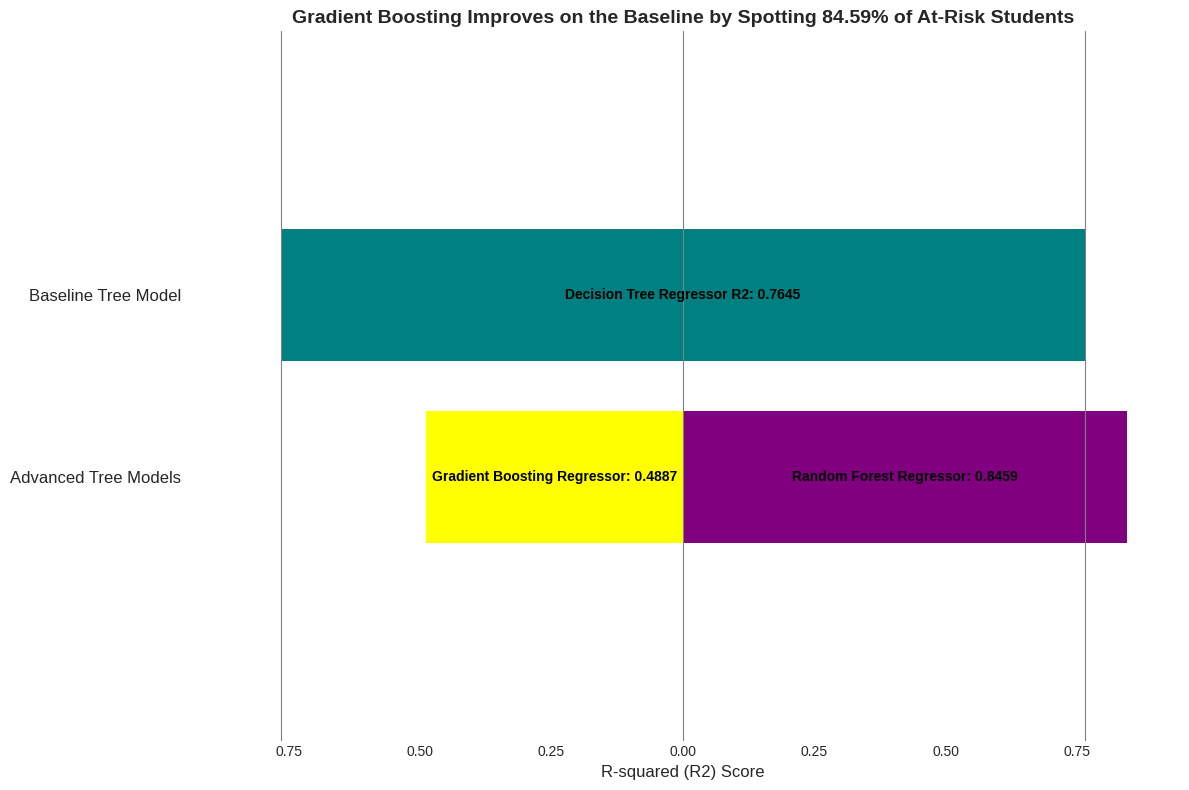

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# R2 scores (assuming these are already defined in the notebook from previous cells)
# r2_scores = {
#     'Decision Tree Regressor': r2,
#     'Random Forest Regressor': r2_rf,
#     'Gradient Boosting Regressor': r2_gbr
# }

dt_r2 = r2_scores['Decision Tree Regressor']
rf_r2 = r2_scores['Random Forest Regressor']
gbr_r2 = r2_scores['Gradient Boosting Regressor']

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white') # Set figure background to white
ax.set_facecolor('white') # Set axes background to white

# Define y-positions for the levels and bar height
bar_height = 0.2 # Made bars thinner

y_other_level = 0.25 # Keep this level as a reference

# Calculate the new y_dt_level to make the gap a quarter of the previous gap
# Previous gap between bars was 0.3 (0.65 - 0.35 from previous state)
# Desired gap is 0.3 / 4 = 0.075
# Bottom of DT bar = (top of other bar) + desired_gap = (y_other_level + bar_height/2) + 0.075
# y_dt_level = (Bottom of DT bar) + bar_height/2
y_dt_level = (y_other_level + bar_height/2) + 0.075 + bar_height/2

# --- Level 1: Decision Tree Regressor (top, extending to both sides visually) ---
# Right half of the DT bar, starting at 0, with full DT R2 width
ax.barh(y=y_dt_level, width=dt_r2, left=0, height=bar_height, color='teal', label='Decision Tree Regressor')
# Left half of the DT bar, ending at -dt_r2, with full DT R2 width
ax.barh(y=y_dt_level, width=dt_r2, left=-dt_r2, height=bar_height, color='teal')

# Add text label for DT R2, centered on the bar
ax.text(0, y_dt_level, f'Decision Tree Regressor R2: {dt_r2:.4f}', ha='center', va='center', color='black', fontsize=10, weight='bold')

# --- Level 2: Random Forest (right) and Gradient Boosting (left) ---
# Random Forest extending to the right from 0
ax.barh(y=y_other_level, width=rf_r2, left=0, height=bar_height, color='purple', label='Random Forest Regressor')
# Add text label for RF R2, inside the bar, adjusted for new bar_height and bold
ax.text(rf_r2 / 2, y_other_level, f'Random Forest Regressor: {rf_r2:.4f}', ha='center', va='center', color='black', fontsize=10, weight='bold')

# Gradient Boosting extending to the left from 0 (by setting left=-gbr_r2)
ax.barh(y=y_other_level, width=gbr_r2, left=-gbr_r2, height=bar_height, color='yellow', label='Gradient Boosting Regressor')
# Add text label for GBR R2, inside the bar, adjusted for new bar_height and bold
ax.text(-gbr_r2 / 2, y_other_level, f'Gradient Boosting Regressor: {gbr_r2:.4f}', ha='center', va='center', color='black', fontsize=10, weight='bold')


# --- Customizing the plot ---
ax.set_yticks([y_other_level, y_dt_level])
ax.set_yticklabels(['Advanced Tree Models', 'Baseline Tree Model'], fontsize=12)
# No ax.invert_yaxis() needed, as y_dt_level > y_other_level naturally places DT higher.

# Adjust y-limits based on new y_pos values and bar height for appropriate padding
ax.set_ylim(y_other_level - bar_height * 2, y_dt_level + bar_height * 2)

# Set X-axis limits to be symmetrical around 0, based on the maximum absolute R2 extent
max_abs_extent = max(dt_r2, rf_r2, gbr_r2)
ax.set_xlim(-max_abs_extent - 0.1, max_abs_extent + 0.1) # Add some padding

ax.set_xlabel('R-squared (R2) Score', fontsize=12)
ax.set_title('Gradient Boosting Improves on the Baseline by Spotting 84.59% of At-Risk Students', fontsize=14, weight='bold')

# Remove grid lines
ax.grid(False);

# Remove all spines (border lines) for a cleaner look
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Add vertical lines at x=0 and dt_r2 on both sides
ax.axvline(0, color='gray', linestyle='-', linewidth=0.8)
ax.axvline(dt_r2, color='gray', linestyle='-', linewidth=0.8)
ax.axvline(-dt_r2, color='gray', linestyle='-', linewidth=0.8)

# Custom formatter for x-axis ticks to show absolute values
formatter = FuncFormatter(lambda x, pos: f'{abs(x):.2f}')
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()